# Machine Learning Capstone Project

## Appliances Energy Prediction

### Review 1 - Regression Track

**Problem Statement:**  
Household appliance energy consumption varies with environmental conditions, weather, and time of day. Accurately predicting energy consumption can help in understanding usage patterns and supporting more efficient energy management.

**Objective:**  
Predict household appliance energy consumption using environmental, weather, and time-related features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 1. Dataset Loading

The Appliances Energy Prediction dataset is loaded for the regression task. The target variable is `Appliances`, which represents appliance energy consumption.

In [2]:
df = pd.read_csv("energydata_complete.csv")

In [3]:
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 19735
Number of columns: 29


In [5]:
print("Columns in the dataset:")
for column in df.columns:
    print(column)

Columns in the dataset:
date
Appliances
lights
T1
RH_1
T2
RH_2
T3
RH_3
T4
RH_4
T5
RH_5
T6
RH_6
T7
RH_7
T8
RH_8
T9
RH_9
T_out
Press_mm_hg
RH_out
Windspeed
Visibility
Tdewpoint
rv1
rv2


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

In [7]:
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


## Missing Values

Check for missing values in the dataset.

In [8]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64


In [9]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


## Duplicate Records

Check for duplicate rows in the dataset.

In [10]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# 2. Data cleaning and Feature Engineering

Remove unnecessary variables and prepare the date information for analysis.

## Remove Unnecessary Variables

The `rv1` and `rv2` variables are random variables and do not provide useful information for prediction, so they are removed.

In [11]:
df = df.drop(columns=["rv1", "rv2"])

print("Shape after removing rv1 and rv2:", df.shape)

Shape after removing rv1 and rv2: (19735, 27)


## Date and Time Feature Engineering

Extract time-related features from the `date` column because appliance energy usage can vary with time.

In [12]:
df['date'] = pd.to_datetime(df['date'])

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday

df = df.drop(columns=['date'])

In [13]:
df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,hour,day,month,weekday
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,6.600000,733.5,92.0,7.000000,63.000000,5.3,17,11,1,0
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,6.483333,733.6,92.0,6.666667,59.166667,5.2,17,11,1,0
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,6.366667,733.7,92.0,6.333333,55.333333,5.1,17,11,1,0
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,6.250000,733.8,92.0,6.000000,51.500000,5.0,17,11,1,0
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,6.133333,733.9,92.0,5.666667,47.666667,4.9,17,11,1,0


# 3. Update Features

Create the feature matrix and target vector after feature engineering.

In [14]:
X = df.drop(columns=["Appliances"])
y = df["Appliances"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (19735, 29)
Target shape: (19735,)


# 4. Target Variable

The target variable for this regression problem is `Appliances`. The objective is to predict appliance energy consumption from the available input features.

In [15]:
target = "Appliances"

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (19735, 29)
Target shape: (19735,)


# 5. Exploratory Data Analysis

Explore the distributions and relationships in the dataset.


## Target Distribution

Visualize the distribution of appliance energy consumption.

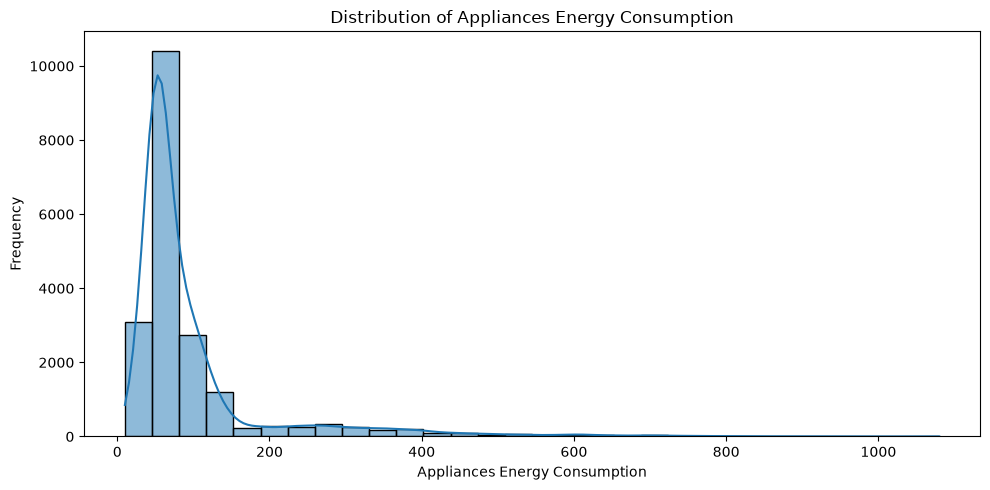

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Appliances"], bins=30, kde=True)

plt.title("Distribution of Appliances Energy Consumption")
plt.xlabel("Appliances Energy Consumption")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

The target variable is concentrated at lower energy consumption values, with a smaller number of observations showing much higher consumption.

### Feature Distributions

Visualize the distribution of each numerical feature.

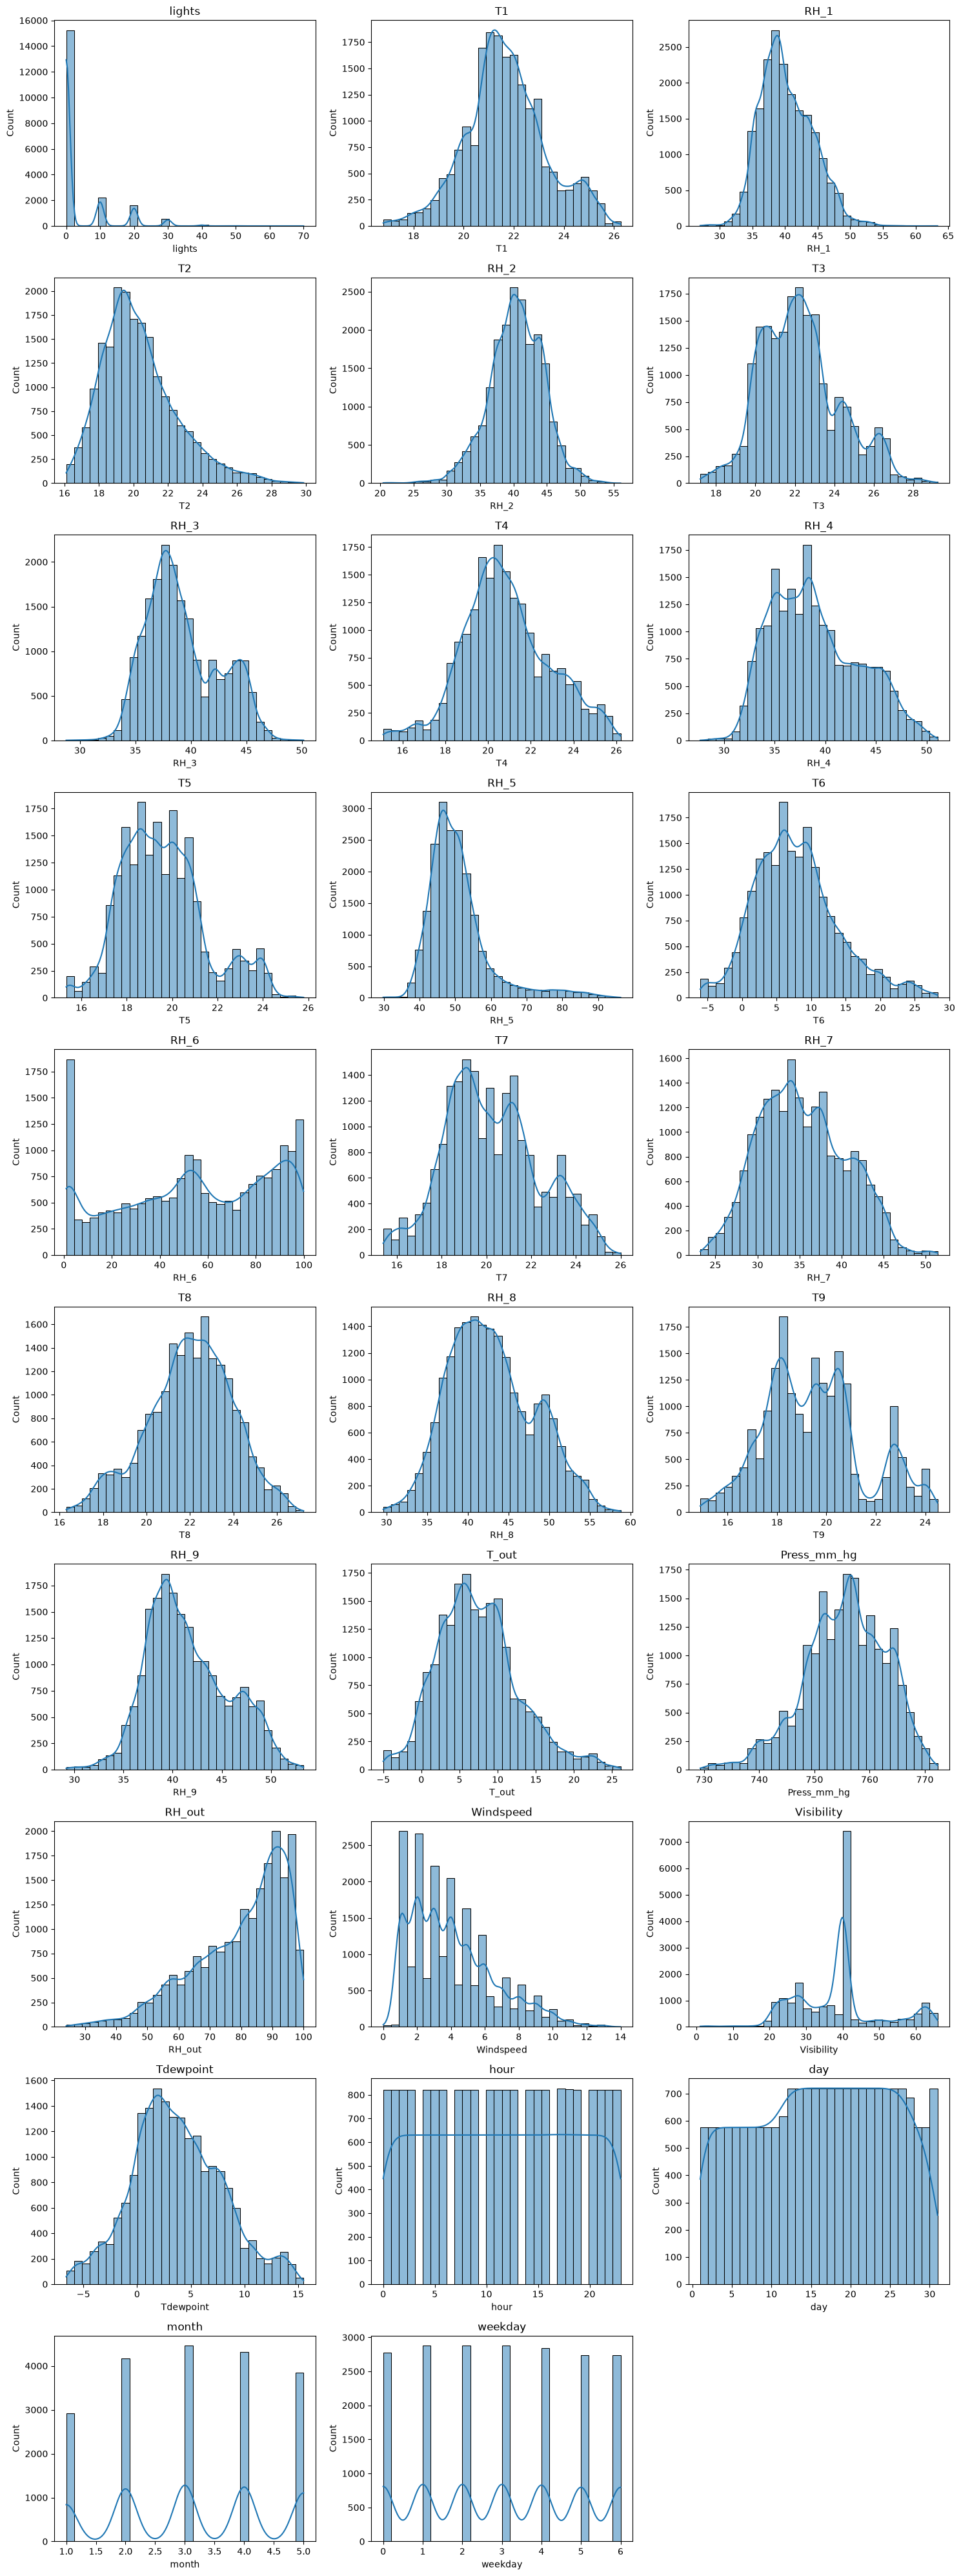

In [17]:
features = X.columns

n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        df[feature],
        bins=30,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(feature)

for i in range(len(features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

### Observation

The features have different ranges and distributions. Some variables show relatively symmetric distributions, while others are skewed or contain extreme values. This supports the need for appropriate preprocessing before model training.

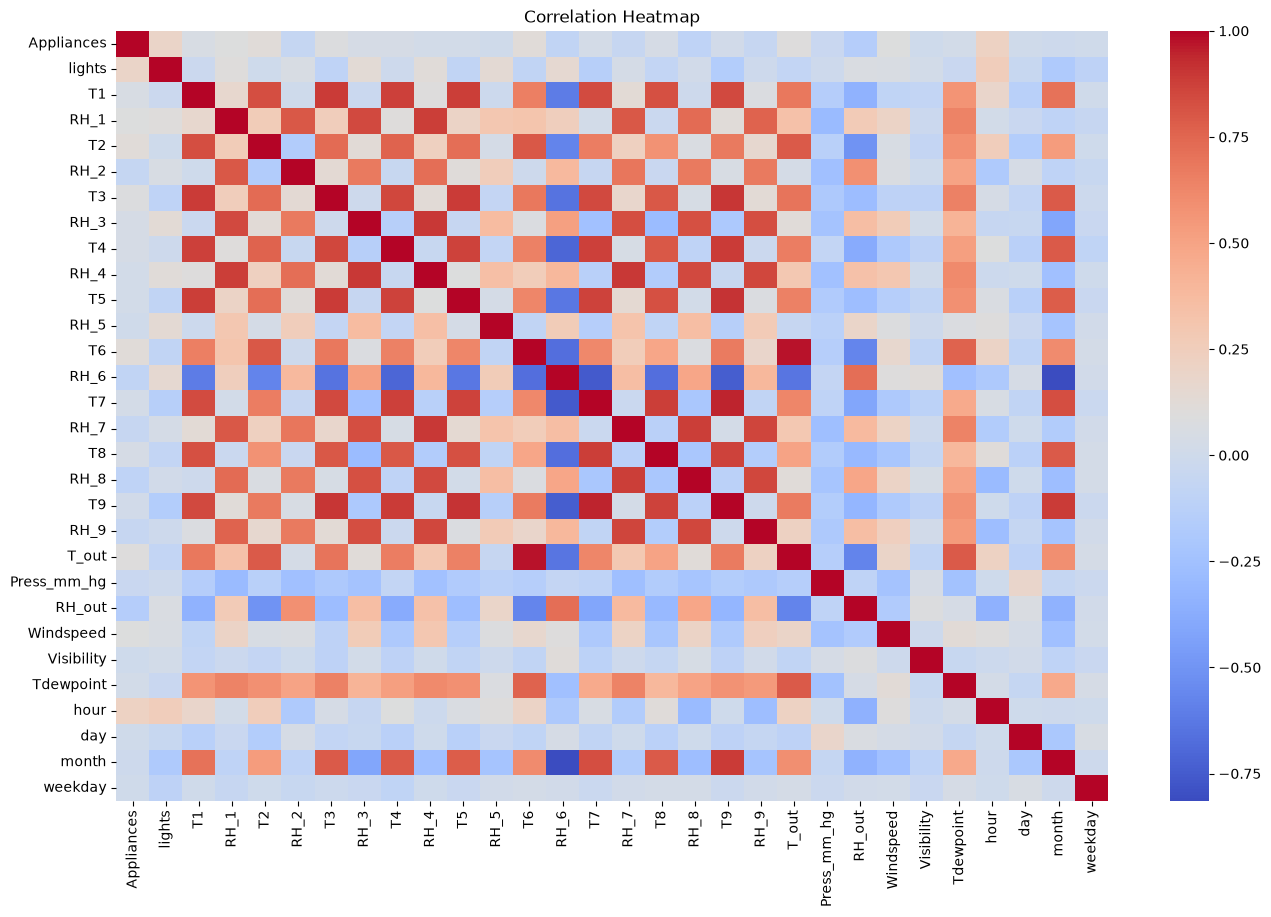

In [18]:
plt.figure(figsize=(16,10))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows varying levels of correlation between appliance energy consumption and the environmental features. Several temperature and humidity variables are also correlated with each other.

## Lights vs Appliances

Examine the relationship between lighting energy use and appliance energy consumption.

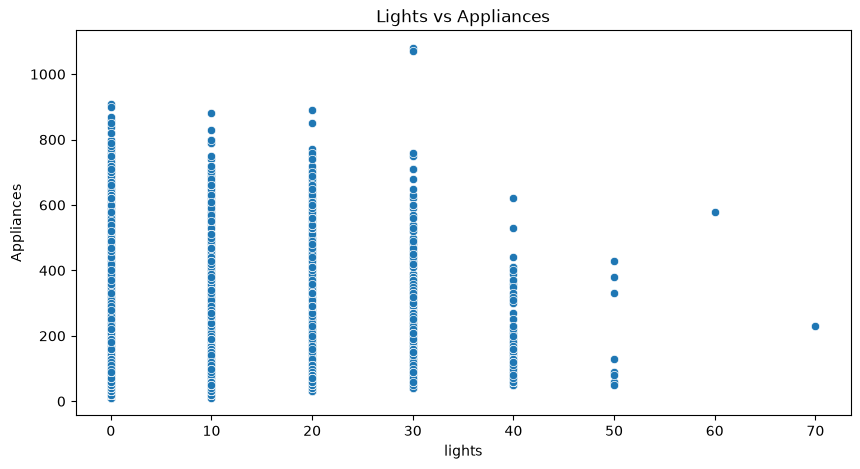

In [19]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df,
    x="lights",
    y="Appliances"
)

plt.title("Lights vs Appliances")

plt.show()

### Observation

The scatter plot shows that appliance energy consumption varies across different lighting usage levels, although the relationship is not perfectly linear.

## Outdoor Temperature vs Appliances

Examine the relationship between outdoor temperature and appliance energy consumption.

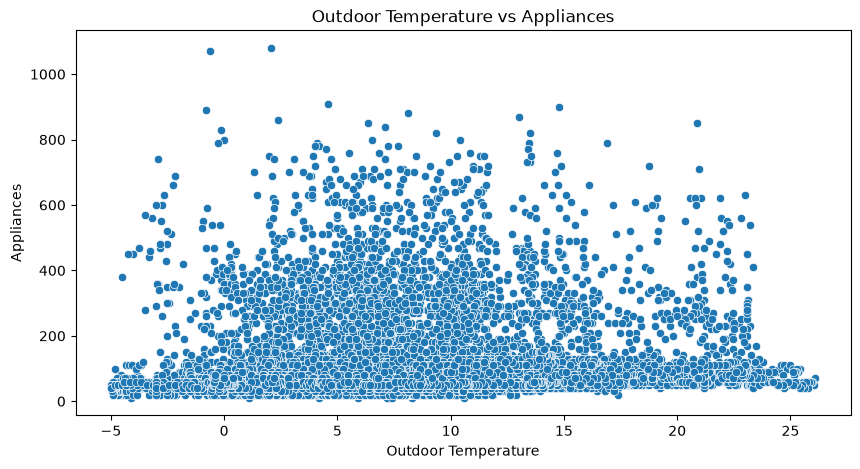

In [20]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="T_out",
    y="Appliances"
)

plt.title("Outdoor Temperature vs Appliances")
plt.xlabel("Outdoor Temperature")
plt.ylabel("Appliances")
plt.show()

### Observation

The plot shows variation in appliance energy consumption across outdoor temperatures, indicating that weather conditions may contribute to changes in energy usage.

# 6. Outlier Detection

Box plots are used to identify potential outliers in the numerical predictor variables.

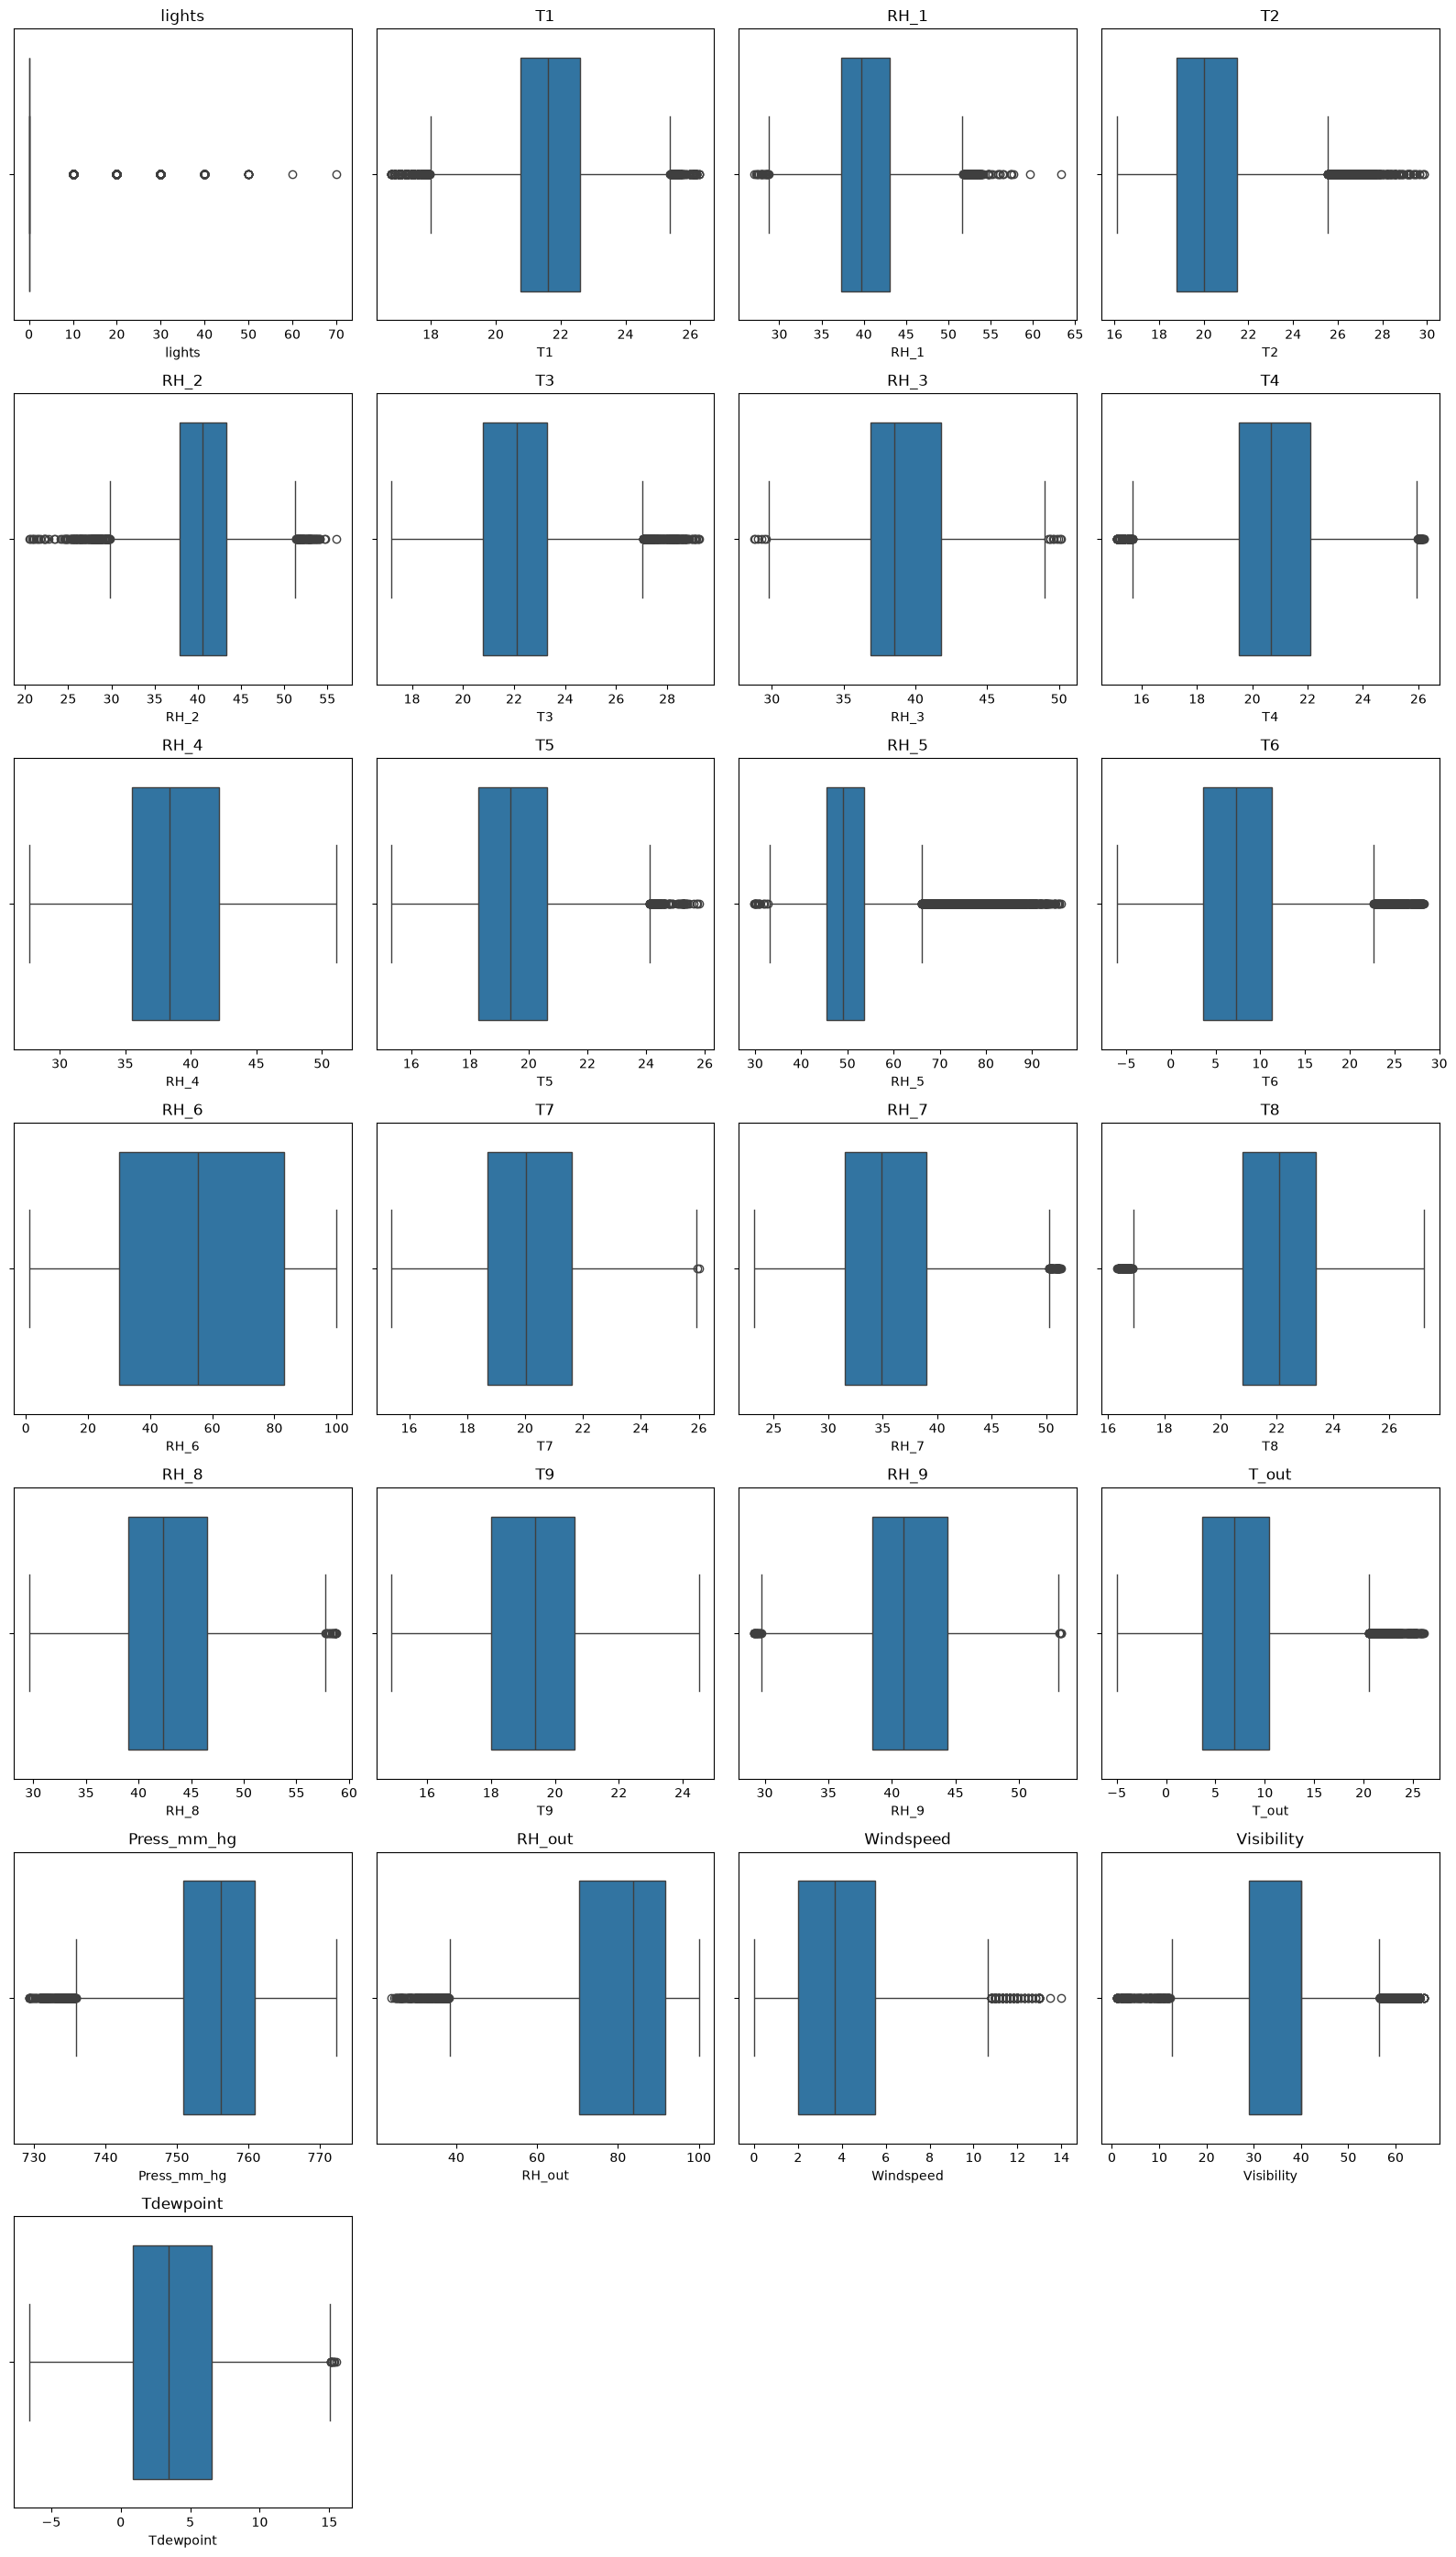

In [21]:

outlier_features = [
    col for col in X.columns
    if col not in ["hour", "day", "month", "weekday"]
]


n_cols = 4
n_rows = int(np.ceil(len(outlier_features) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(outlier_features):
    sns.boxplot(
        x=X[feature],
        ax=axes[i]
    )
    axes[i].set_title(feature)

for i in range(len(outlier_features), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

## IQR-Based Outlier Detection

The Interquartile Range (IQR) method is used to identify potential outliers numerically.

In [22]:

Q1 = X[outlier_features].quantile(0.25)
Q3 = X[outlier_features].quantile(0.75)

IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outlier_counts = (
    (X[outlier_features] < lower_bound) |
    (X[outlier_features] > upper_bound)
).sum()

outlier_summary = pd.DataFrame({
    "Feature": outlier_features,
    "Outlier Count": outlier_counts.values
})

outlier_summary = outlier_summary.sort_values(
    by="Outlier Count",
    ascending=False
)

outlier_summary

,Feature,Outlier Count
0,lights,4483
23,Visibility,2522
10,RH_5,1330
3,T2,546
1,T1,515
11,T6,515
19,T_out,436
21,RH_out,239
4,RH_2,235
20,Press_mm_hg,219


# 7. Train Test Split

Split the dataset into training and testing data using an 80:20 ratio.

In [23]:

y_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates="drop"
)

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y_bins
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (15788, 29)
Testing set shape: (3947, 29)


# 8. Outlier Treatment

Apply IQR-based capping using statistics calculated only from the training data.

In [24]:

Q1_train = X_train[outlier_features].quantile(0.25)
Q3_train = X_train[outlier_features].quantile(0.75)

IQR_train = Q3_train - Q1_train

lower_bound_train = Q1_train - 1.5 * IQR_train
upper_bound_train = Q3_train + 1.5 * IQR_train


X_train[outlier_features] = X_train[outlier_features].clip(
    lower=lower_bound_train,
    upper=upper_bound_train,
    axis=1
)


X_test[outlier_features] = X_test[outlier_features].clip(
    lower=lower_bound_train,
    upper=upper_bound_train,
    axis=1
)

print("Outlier treatment completed using IQR capping.")

Outlier treatment completed using IQR capping.


# 9. Feature Scaling

Standardize the features before training models that require scaling.

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10. Linear Regression

Train a Linear Regression model and generate predictions.

In [26]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

# 11. Ridge Regression

Train a Ridge Regression model and generate predictions.

In [27]:
ridge_model = Ridge()

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

# 12. Lasso Regression

Train a Lasso Regression model and generate predictions.

In [28]:
lasso_model = Lasso()

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

# 13. ElasticNet Regression

Train an ElasticNet Regression model and generate predictions.

In [29]:
elastic_model = ElasticNet()

elastic_model.fit(X_train_scaled, y_train)

y_pred_elastic = elastic_model.predict(X_test_scaled)

# 14. Polynomial Regression

Transform the features into polynomial features and train a Linear Regression model.

In [30]:
polynomial_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])

polynomial_model.fit(X_train_scaled, y_train)

y_pred_poly = polynomial_model.predict(X_test_scaled)

# 15. Decision Tree Regression

Train a Decision Tree Regression model and generate predictions.

In [31]:
dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

# 16. Random Forest Regression

Train a Random Forest Regression model and generate predictions.

In [32]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# 17. Gradient Boosting Regression

Train a Gradient Boosting Regression model and generate predictions.

In [33]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

# 18. Support Vector Regression

Train a Support Vector Regression model and generate predictions.

In [34]:
svr_model = SVR()

svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

# 19. K-Nearest Neighbors Regression

Train a K-Nearest Neighbors Regression model and generate predictions.

In [35]:
knn_model = KNeighborsRegressor()

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

# 20. Model Comparison

Compare all ten regression models using R², RMSE, and MAE on the same test set.

In [36]:
results = []

predictions = {
    "Linear Regression": y_pred_linear,
    "Ridge Regression": y_pred_ridge,
    "Lasso Regression": y_pred_lasso,
    "ElasticNet Regression": y_pred_elastic,
    "Polynomial Regression": y_pred_poly,
    "Decision Tree Regression": y_pred_dt,
    "Random Forest Regression": y_pred_rf,
    "Gradient Boosting Regression": y_pred_gb,
    "Support Vector Regression": y_pred_svr,
    "K-Nearest Neighbors Regression": y_pred_knn
}

for model_name, y_pred in predictions.items():

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append([
        model_name,
        r2,
        rmse,
        mae
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R²", "RMSE", "MAE"]
)

results_df = results_df.sort_values(
    by="R²",
    ascending=False
).reset_index(drop=True)

results_df

,Model,R²,RMSE,MAE
0,Random Forest Regression,0.598818,61.738239,28.790702
1,K-Nearest Neighbors Regression,0.489673,69.631772,32.314163
2,Gradient Boosting Regression,0.308693,81.043631,44.011425
3,Polynomial Regression,0.300887,81.499906,48.639258
4,Decision Tree Regression,0.214877,86.367889,35.741069
5,Ridge Regression,0.138805,90.455339,52.309485
6,Linear Regression,0.138775,90.456865,52.314347
7,Lasso Regression,0.128422,90.998971,51.992265
8,ElasticNet Regression,0.085215,93.227253,53.618363
9,Support Vector Regression,0.024149,96.288634,41.486152


# 21. R² Comparison

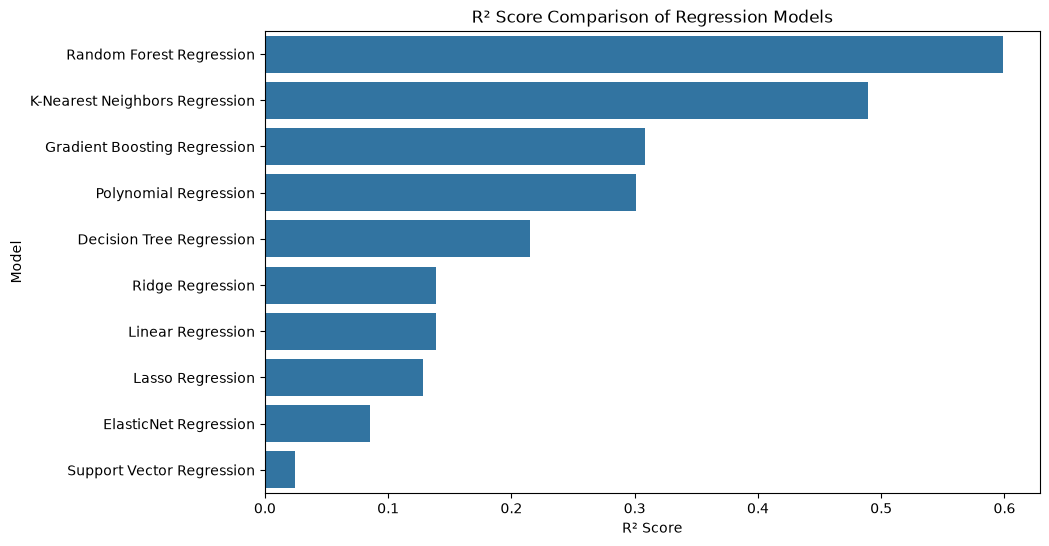

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="R²",
    y="Model"
)

plt.title("R² Score Comparison of Regression Models")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.show()

## Observation

The R² comparison provides a visual view of the performance differences among the ten regression models.

# 22. Hyperparameter Tuning

Hyperparameter tuning is used to find suitable model settings that can improve prediction performance.

The three best-performing models from the initial comparison are selected for tuning:
Random Forest Regression, K-Nearest Neighbors Regression, and Gradient Boosting Regression.

##  Random Forest Hyperparameter Tuning

GridSearchCV is used to find the best number of trees and tree depth for the Random Forest model.

In [38]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

In [40]:
rf_param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train);

In [41]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation R²:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation R²:
0.5034227648542076


In [42]:
best_rf_model = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf_model.predict(X_test)

r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)

print("Tuned Random Forest")
print("R²  :", r2_rf_tuned)
print("RMSE:", rmse_rf_tuned)
print("MAE :", mae_rf_tuned)

Tuned Random Forest
R²  : 0.602495529096418
RMSE: 61.45459295951451
MAE : 28.736749429946794


##  K-Nearest Neighbors Hyperparameter Tuning

GridSearchCV is used to find the best number of neighbors for the K-Nearest Neighbors model.

In [43]:
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 20]
}

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    param_grid=knn_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

knn_grid.fit(X_train_scaled, y_train);

In [44]:
print("Best KNN Parameters:")
print(knn_grid.best_params_)

print("\nBest Cross-Validation R²:")
print(knn_grid.best_score_)

Best KNN Parameters:
{'n_neighbors': 3}

Best Cross-Validation R²:
0.4275383335195224


In [45]:
best_knn_model = knn_grid.best_estimator_

y_pred_knn_tuned = best_knn_model.predict(X_test_scaled)

r2_knn_tuned = r2_score(y_test, y_pred_knn_tuned)
rmse_knn_tuned = np.sqrt(mean_squared_error(y_test, y_pred_knn_tuned))
mae_knn_tuned = mean_absolute_error(y_test, y_pred_knn_tuned)

print("Tuned K-Nearest Neighbors")
print("R²  :", r2_knn_tuned)
print("RMSE:", rmse_knn_tuned)
print("MAE :", mae_knn_tuned)

Tuned K-Nearest Neighbors
R²  : 0.5431712580249146
RMSE: 65.88097954159812
MAE : 29.217126931846973


##  Gradient Boosting Hyperparameter Tuning

GridSearchCV is used to find suitable learning rate and tree depth values for the Gradient Boosting model.

In [46]:
gb_param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "n_estimators": [100, 150, 200],
    "max_depth": [2, 3, 4]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(
        random_state=42
    ),
    param_grid=gb_param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train);

In [47]:
print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

print("\nBest Cross-Validation R²:")
print(gb_grid.best_score_)

Best Gradient Boosting Parameters:
{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}

Best Cross-Validation R²:
0.3987762417378426


In [48]:
best_gb_model = gb_grid.best_estimator_

y_pred_gb_tuned = best_gb_model.predict(X_test)

r2_gb_tuned = r2_score(y_test, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))
mae_gb_tuned = mean_absolute_error(y_test, y_pred_gb_tuned)

print("Tuned Gradient Boosting")
print("R²  :", r2_gb_tuned)
print("RMSE:", rmse_gb_tuned)
print("MAE :", mae_gb_tuned)

Tuned Gradient Boosting
R²  : 0.45621064995294736
RMSE: 71.87844722107008
MAE : 37.55254207520885


# 23. Hyperparameter Tuning Comparison

Compare the original and tuned models to measure the change in R².

In [50]:
# Get the original R² values from the 10-model comparison table

original_r2 = results_df.set_index("Model")["R²"]

tuning_results = pd.DataFrame({
    "Model": [
        "Random Forest Regression",
        "K-Nearest Neighbors Regression",
        "Gradient Boosting Regression"
    ],
    "Original R²": [
        original_r2["Random Forest Regression"],
        original_r2["K-Nearest Neighbors Regression"],
        original_r2["Gradient Boosting Regression"]
    ],
    "Tuned R²": [
        r2_rf_tuned,
        r2_knn_tuned,
        r2_gb_tuned
    ]
})

tuning_results["R² Improvement"] = (
    tuning_results["Tuned R²"] -
    tuning_results["Original R²"]
)

tuning_results

,Model,Original R²,Tuned R²,R² Improvement
0,Random Forest Regression,0.598818,0.602496,0.003678
1,K-Nearest Neighbors Regression,0.489673,0.543171,0.053498
2,Gradient Boosting Regression,0.308693,0.456211,0.147518


# 24. 5-Fold Cross-Validation

5-fold cross-validation is used to evaluate the consistency of the two best-performing models using the training data.

## Random Forest Cross-Validation

Evaluate the Random Forest model using 5-fold cross-validated R².

In [52]:
rf_cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Random Forest 5-Fold R² Scores:")
print(rf_cv_scores)

print("\nMean Cross-Validated R²:", rf_cv_scores.mean())

Random Forest 5-Fold R² Scores:
[0.56302204 0.5399867  0.54590215 0.54565217 0.56936148]

Mean Cross-Validated R²: 0.5527849082644026


##  K-Nearest Neighbors Cross-Validation

Evaluate the K-Nearest Neighbors model using 5-fold cross-validated R².

In [53]:
knn_cv_scores = cross_val_score(
    knn_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("K-Nearest Neighbors 5-Fold R² Scores:")
print(knn_cv_scores)

print("\nMean Cross-Validated R²:", knn_cv_scores.mean())

K-Nearest Neighbors 5-Fold R² Scores:
[0.45958973 0.39835514 0.43916448 0.40036755 0.46243274]

Mean Cross-Validated R²: 0.4319819257975797


### Cross-Validation Comparison

In [54]:
cv_results = pd.DataFrame({
    "Model": [
        "Random Forest Regression",
        "K-Nearest Neighbors Regression"
    ],
    "Mean 5-Fold R²": [
        rf_cv_scores.mean(),
        knn_cv_scores.mean()
    ]
})

cv_results

,Model,Mean 5-Fold R²
0,Random Forest Regression,0.552785
1,K-Nearest Neighbors Regression,0.431982


# 25. Final Model Selection

The tuned models are compared using their test-set R² scores to select the model for final visualisation.

In [55]:
final_model_results = pd.DataFrame({
    "Model": [
        "Random Forest Regression",
        "K-Nearest Neighbors Regression",
        "Gradient Boosting Regression"
    ],
    "Tuned R²": [
        r2_rf_tuned,
        r2_knn_tuned,
        r2_gb_tuned
    ]
})

final_model_results = final_model_results.sort_values(
    by="Tuned R²",
    ascending=False
).reset_index(drop=True)

final_model_results

,Model,Tuned R²
0,Random Forest Regression,0.602496
1,K-Nearest Neighbors Regression,0.543171
2,Gradient Boosting Regression,0.456211


### Final Model

The model with the highest tuned test-set R² is selected for the final prediction and residual visualisations.

In [56]:
best_model_name = final_model_results.loc[0, "Model"]

if best_model_name == "Random Forest Regression":
    final_model = best_rf_model
    final_predictions = y_pred_rf_tuned

elif best_model_name == "K-Nearest Neighbors Regression":
    final_model = best_knn_model
    final_predictions = y_pred_knn_tuned

else:
    final_model = best_gb_model
    final_predictions = y_pred_gb_tuned

print("Final Model:", best_model_name)

Final Model: Random Forest Regression


# 26. Predicted vs Actual

The predicted values are compared with the actual appliance energy consumption values.

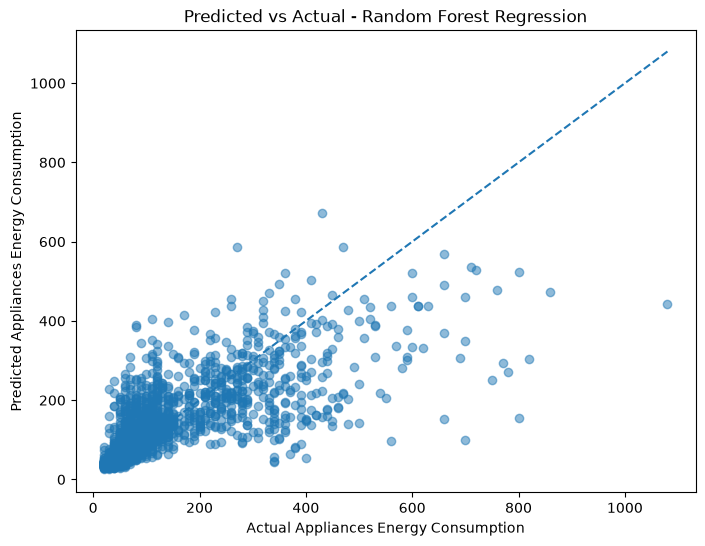

In [57]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Appliances Energy Consumption")
plt.ylabel("Predicted Appliances Energy Consumption")
plt.title(f"Predicted vs Actual - {best_model_name}")

plt.show()

### Observation

The predicted values are compared with the actual values. Points closer to the diagonal line indicate predictions that are closer to the actual appliance energy consumption.

# 27. Residual Plot

Residuals are calculated as the difference between the actual and predicted values.

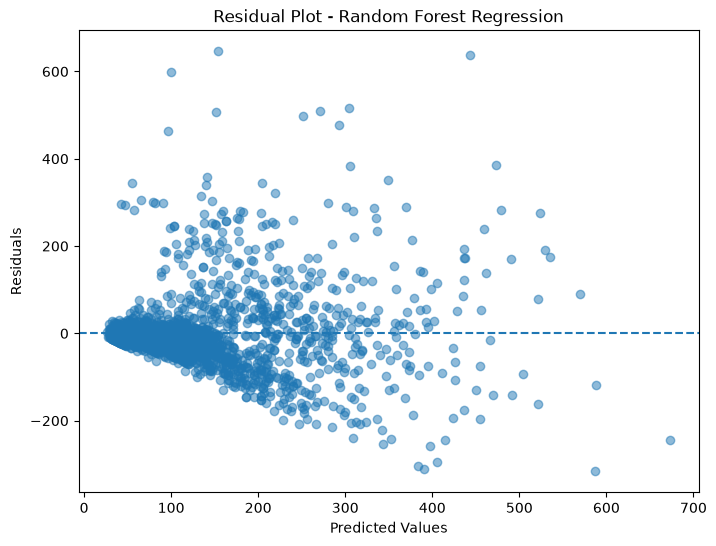

In [58]:
residuals = y_test - final_predictions

plt.figure(figsize=(8, 6))

plt.scatter(
    final_predictions,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(f"Residual Plot - {best_model_name}")

plt.show()

### Observation

The residual plot shows the prediction errors around the zero reference line. A relatively random distribution of residuals around zero indicates that the model does not show a strong systematic prediction pattern.

# 28. Feature Importance

Feature importance from the tuned Random Forest model is used to identify the predictor variables that contribute most to the model's predictions.

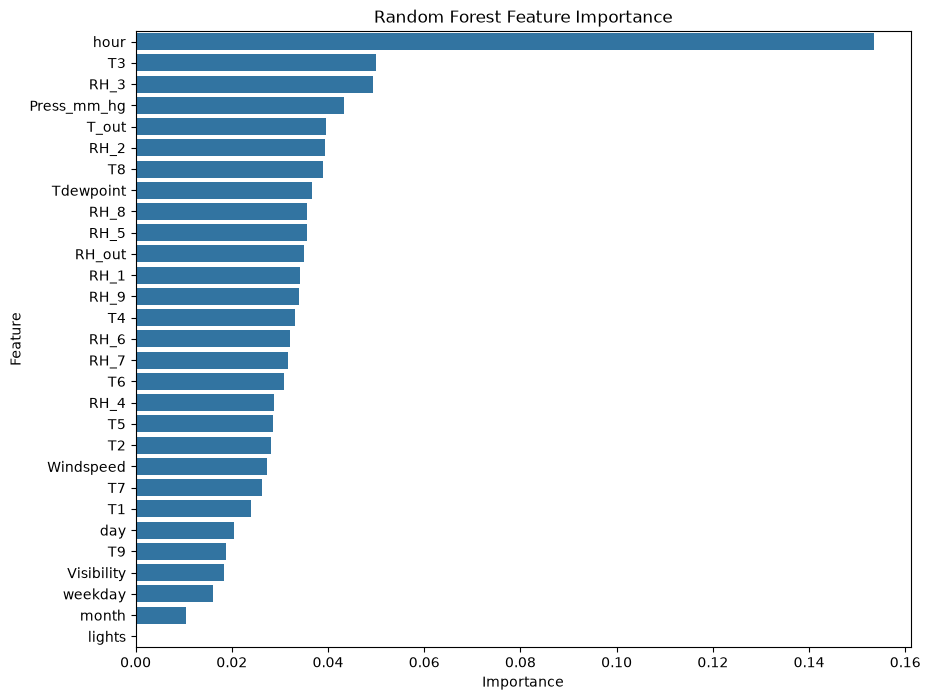

In [59]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Observation

The feature importance plot shows the relative contribution of the predictor variables to the Random Forest model. Features with higher importance have a greater influence on the model's predictions.

# 29. Final Model Evaluation

The final model is evaluated on the held-out test set using R², RMSE, and MAE.

In [60]:
final_r2 = r2_score(y_test, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
final_mae = mean_absolute_error(y_test, final_predictions)

final_results = pd.DataFrame({
    "Metric": ["R²", "RMSE", "MAE"],
    "Value": [final_r2, final_rmse, final_mae]
})

final_results

,Metric,Value
0,R²,0.602496
1,RMSE,61.454593
2,MAE,28.736749


# 30. Conclusion

The Appliances Energy Prediction dataset was analyzed and used to build multiple regression models.

Ten regression algorithms were compared using R², RMSE, and MAE on the same test set. Hyperparameter tuning was then performed on the top three models, followed by 5-fold cross-validation for the two best-performing models.

The final model was selected based on its tuned test-set performance. Predicted-vs-actual, residual, and feature-importance plots were used to further analyze its performance and the influence of the input features.